# Movie Rating Prediction with Python

This notebook builds a machine learning model to predict movie ratings based on features like genre, director, and actors.

**Workflow:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Model Building (Regression)
5. Model Evaluation
6. Insights & Conclusions

## 1. Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Dataset

In [ ]:
# Load the dataset

df = pd.read_csv('data/IMDb_Movies_India.csv', encoding='latin-1')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset shape: (15509, 10)
Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,-1997.0,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,-2005.0,142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,-2008.0,59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,-2012.0,82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,-2014.0,116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [39]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [40]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Duration,8269,53.32
Rating,7590,48.94
Votes,7589,48.93
Actor 3,3144,20.27
Actor 2,2384,15.37
Genre,1877,12.10
Actor 1,1617,10.43
Year,528,3.40
Director,525,3.39


## 3. Data Cleaning & Preprocessing

In [41]:
# --- Clean column names ---
df.columns = df.columns.str.strip()

# --- Clean 'Year': remove '-' prefix and convert to int ---
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# --- Clean 'Duration': remove 'min' and convert to int ---
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# --- Clean 'Votes': remove commas and convert to int ---
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# --- Clean 'Rating': ensure numeric ---
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# --- Strip whitespace from string columns ---
for col in ['Name', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

print('Cleaning done!')
print(df.dtypes)
df.head()

Cleaning done!
Name         object
Year        float64
Duration    float64
Genre        object
Rating      float64
Votes       float64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,90.0,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,105.0,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [42]:
# Drop rows with no Rating (target variable)
df_model = df.dropna(subset=['Rating']).copy()
print(f'Rows with valid Rating: {len(df_model)} / {len(df)} total')

Rows with valid Rating: 7919 / 15509 total


## 4. Exploratory Data Analysis (EDA)

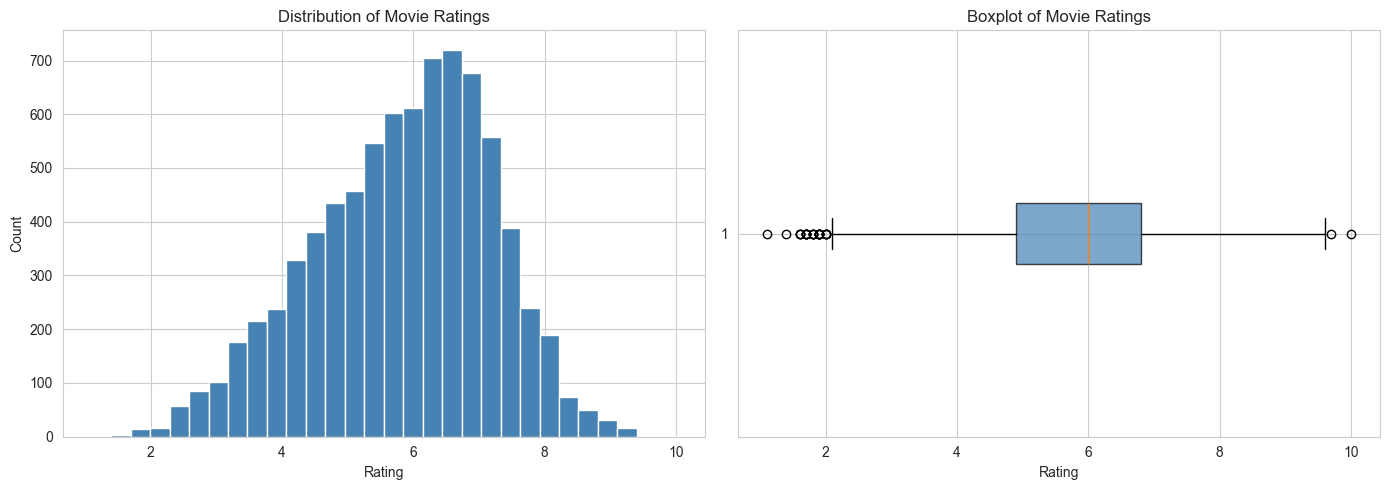

count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [43]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Movie Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

axes[1].boxplot(df_model['Rating'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Movie Ratings')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()
print(df_model['Rating'].describe())

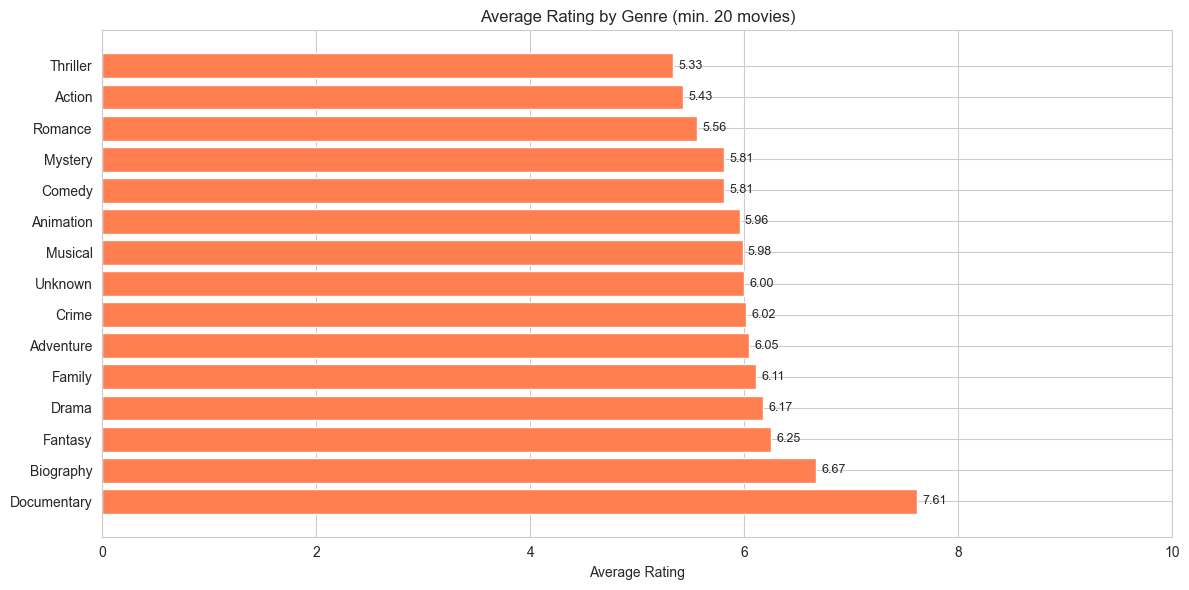

In [44]:
# Top genres by average rating
df_model['Primary_Genre'] = df_model['Genre'].fillna('Unknown').apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)

genre_stats = df_model.groupby('Primary_Genre')['Rating'].agg(['mean', 'count'])
genre_stats = genre_stats[genre_stats['count'] >= 20].sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(genre_stats.index, genre_stats['mean'], color='coral', edgecolor='white')
plt.xlabel('Average Rating')
plt.title('Average Rating by Genre (min. 20 movies)')
plt.xlim(0, 10)
for bar, val in zip(bars, genre_stats['mean']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

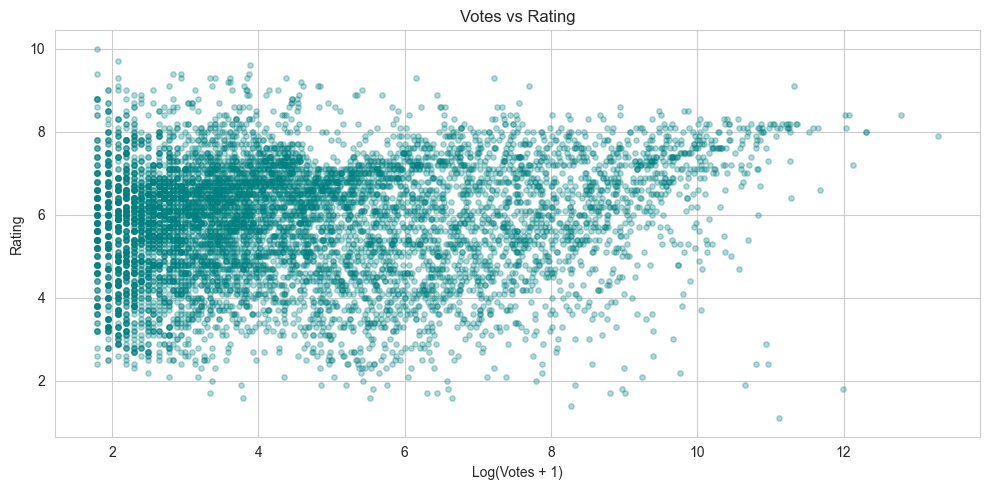

Correlation with Rating:
Rating      1.000000
Votes       0.126635
Duration   -0.031093
Year       -0.166673
Name: Rating, dtype: float64


In [45]:
# Votes vs Rating scatter
plt.figure(figsize=(10, 5))
plt.scatter(np.log1p(df_model['Votes']), df_model['Rating'], alpha=0.3, color='teal', s=15)
plt.xlabel('Log(Votes + 1)')
plt.ylabel('Rating')
plt.title('Votes vs Rating')
plt.tight_layout()
plt.show()

corr = df_model[['Rating', 'Votes', 'Duration', 'Year']].corr()
print('Correlation with Rating:')
print(corr['Rating'].sort_values(ascending=False))

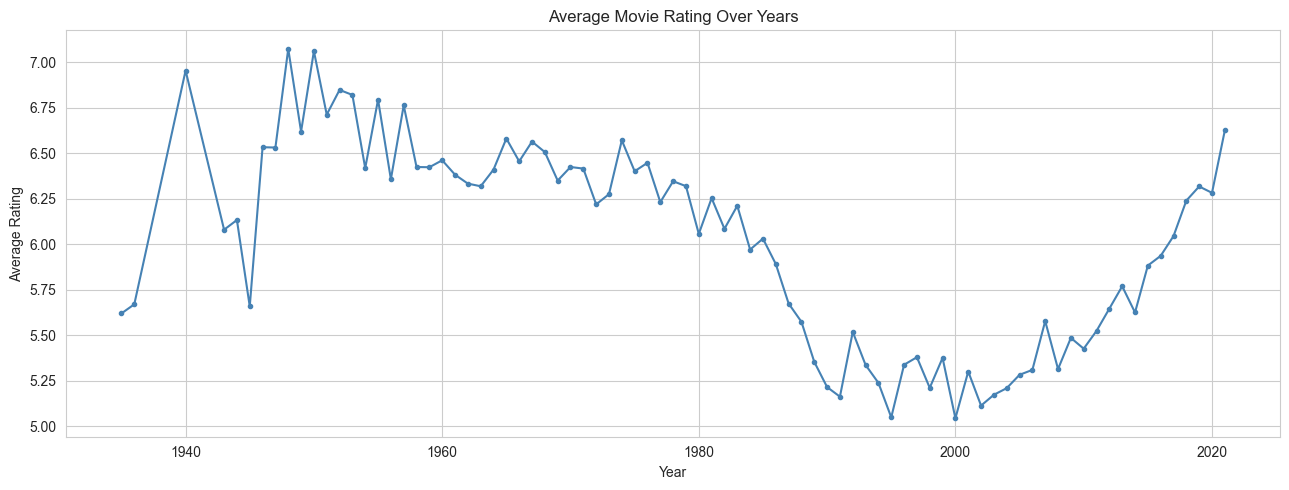

In [46]:
# Ratings trend over years
year_rating = df_model.groupby('Year')['Rating'].agg(['mean', 'count'])
year_rating = year_rating[year_rating['count'] >= 10]

plt.figure(figsize=(13, 5))
plt.plot(year_rating.index, year_rating['mean'], color='steelblue', marker='o', markersize=3)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Movie Rating Over Years')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [47]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

df_feat = train_df.copy()

df_feat['Votes'] = df_feat['Votes'].fillna(df_feat['Votes'].median())
df_feat['Duration'] = df_feat['Duration'].fillna(df_feat['Duration'].median())
df_feat['Year'] = df_feat['Year'].fillna(df_feat['Year'].median())

# --- Log-transform Votes (handles skewness) ---
df_feat['Log_Votes'] = np.log1p(df_feat['Votes'])

# --- Movie age ---
CURRENT_YEAR = df['Year'].max()
df_feat['Movie_Age'] = CURRENT_YEAR - df_feat['Year']

# --- Number of genres ---
df_feat['Num_Genres'] = df_feat['Genre'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0
)

# --- Director average rating (target encoding) ---
director_mean = df_feat.groupby('Director')['Rating'].mean()
director_count = df_feat.groupby('Director')['Rating'].count()
global_mean = df_feat['Rating'].mean()
# Smoothed target encoding
k = 5
director_smooth = (director_count * director_mean + k * global_mean) / (director_count + k)
df_feat['Director_Avg_Rating'] = df_feat['Director'].map(director_smooth).fillna(global_mean)

# --- Actor 1 average rating ---
actor1_mean = df_feat.groupby('Actor 1')['Rating'].mean()
actor1_count = df_feat.groupby('Actor 1')['Rating'].count()
actor1_smooth = (actor1_count * actor1_mean + k * global_mean) / (actor1_count + k)
df_feat['Actor1_Avg_Rating'] = df_feat['Actor 1'].map(actor1_smooth).fillna(global_mean)

# Actor 2
actor2_mean = df_feat.groupby('Actor 2')['Rating'].mean()
actor2_count = df_feat.groupby('Actor 2')['Rating'].count()
actor2_smooth = (actor2_count * actor2_mean + k * global_mean) / (actor2_count + k)
df_feat['Actor2_Avg_Rating'] = df_feat['Actor 2'].map(actor2_smooth).fillna(global_mean)

# Actor 3
actor3_mean = df_feat.groupby('Actor 3')['Rating'].mean()
actor3_count = df_feat.groupby('Actor 3')['Rating'].count()
actor3_smooth = (actor3_count * actor3_mean + k * global_mean) / (actor3_count + k)
df_feat['Actor3_Avg_Rating'] = df_feat['Actor 3'].map(actor3_smooth).fillna(global_mean)

# Combine all actors
def safe_actor_avg(row):
    vals = []

    if pd.notna(row['Actor1_Avg_Rating']):
        vals.append(row['Actor1_Avg_Rating'])
    if pd.notna(row['Actor2_Avg_Rating']):
        vals.append(row['Actor2_Avg_Rating'])
    if pd.notna(row['Actor3_Avg_Rating']):
        vals.append(row['Actor3_Avg_Rating'])

    return np.mean(vals) if vals else global_mean

df_feat['Actors_Avg_Rating'] = df_feat.apply(safe_actor_avg, axis=1)

# --- Genre dummies (top genres) ---
top_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller', 'Crime', 'Horror', 'Biography']
for g in top_genres:
    df_feat[f'Genre_{g}'] = df_feat['Genre'].fillna('').apply(lambda x: int(g in [i.strip() for i in x.split(',')]))

df_feat[['Rating', 'Log_Votes', 'Movie_Age', 'Num_Genres', 'Director_Avg_Rating', 'Actor1_Avg_Rating']].head()

df_test_feat = test_df.copy()
df_test_feat['Votes'] = df_test_feat['Votes'].fillna(df_feat['Votes'].median())
df_test_feat['Duration'] = df_test_feat['Duration'].fillna(df_feat['Duration'].median())
df_test_feat['Year'] = df_test_feat['Year'].fillna(df_feat['Year'].median())

# --- SAME feature engineering for test data ---

df_test_feat['Log_Votes'] = np.log1p(df_test_feat['Votes'])
df_test_feat['Movie_Age'] = CURRENT_YEAR - df_test_feat['Year']

df_test_feat['Num_Genres'] = df_test_feat['Genre'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0
)

# Use SAME mappings from TRAIN
df_test_feat['Director_Avg_Rating'] = df_test_feat['Director'].map(director_smooth).fillna(global_mean)

df_test_feat['Actor1_Avg_Rating'] = df_test_feat['Actor 1'].map(actor1_smooth).fillna(global_mean)
df_test_feat['Actor2_Avg_Rating'] = df_test_feat['Actor 2'].map(actor2_smooth).fillna(global_mean)
df_test_feat['Actor3_Avg_Rating'] = df_test_feat['Actor 3'].map(actor3_smooth).fillna(global_mean)

df_test_feat['Actors_Avg_Rating'] = df_test_feat.apply(safe_actor_avg, axis=1)

# Genre features
for g in top_genres:
    df_test_feat[f'Genre_{g}'] = df_test_feat['Genre'].fillna('').apply(lambda x: int(g in [i.strip() for i in x.split(',')]))

## 6. Prepare Data for Modeling

In [48]:
feature_cols = (
    ['Duration', 'Log_Votes', 'Movie_Age', 'Num_Genres',
     'Director_Avg_Rating', 'Actors_Avg_Rating']
    + [f'Genre_{g}' for g in top_genres]
)

X = df_feat[feature_cols]
y = df_feat['Rating']

# Impute remaining NaNs
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)

# Prepare TEST data (basic version)
X_test = df_test_feat[feature_cols]
y_test = df_test_feat['Rating']

# Apply SAME imputer
X_test = imputer.transform(X_test)
X_test = pd.DataFrame(X_test, columns=feature_cols)

# Training data
X_train = X_imputed
y_train = y

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (6335, 14)
Test set:     (1584, 14)


## 7. Model Training & Comparison

In [49]:
# -------------------- Models --------------------
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor

models = {
    'Linear Regression':        LinearRegression(),
    'Ridge Regression':         Ridge(alpha=1.0),
    'Lasso Regression':         Lasso(alpha=0.1),
    'Decision Tree':            DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':            RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees':              ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':                  XGBRegressor(
                                    n_estimators=300,
                                    learning_rate=0.05,
                                    max_depth=6,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    random_state=42,
                                    n_jobs=-1
                                ),
    'LightGBM':                 LGBMRegressor(
                                    n_estimators=300,
                                    learning_rate=0.05,
                                    max_depth=-1,
                                    random_state=42
                                ),
}

results = []

# -------------------- Cross Validation --------------------
from sklearn.model_selection import cross_val_score

print("\nRunning Cross-Validation for Random Forest...\n")

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

# -------------------- Model Evaluation --------------------
for name, model in models.items():
    
    #FIX: keep dataframe (don’t use .values)
    X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })

    print(f'{name:30s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

# -------------------- Results --------------------
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
results_df


Running Cross-Validation for Random Forest...

Cross-Validation R² Scores: [0.73191299 0.73531112 0.74072484 0.73487225 0.71136726]
Average CV R²: 0.7308376893619
Linear Regression               MAE=0.9108  RMSE=1.1774  R²=0.2544
Ridge Regression                MAE=0.9107  RMSE=1.1772  R²=0.2545
Lasso Regression                MAE=0.9161  RMSE=1.1819  R²=0.2486
Decision Tree                   MAE=0.9382  RMSE=1.2307  R²=0.1853
Random Forest                   MAE=0.8755  RMSE=1.1523  R²=0.2858
Gradient Boosting               MAE=0.8801  RMSE=1.1520  R²=0.2861
Extra Trees                     MAE=0.8773  RMSE=1.1493  R²=0.2895
XGBoost                         MAE=0.8416  RMSE=1.1168  R²=0.3291
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1019
[LightGBM] [Info] Number of data points 

,Model,MAE,RMSE,R²
7,XGBoost,0.8416,1.1168,0.3291
8,LightGBM,0.8462,1.1238,0.3207
6,Extra Trees,0.8773,1.1493,0.2895
5,Gradient Boosting,0.8801,1.1520,0.2861
4,Random Forest,0.8755,1.1523,0.2858
1,Ridge Regression,0.9107,1.1772,0.2545
0,Linear Regression,0.9108,1.1774,0.2544
2,Lasso Regression,0.9161,1.1819,0.2486
3,Decision Tree,0.9382,1.2307,0.1853


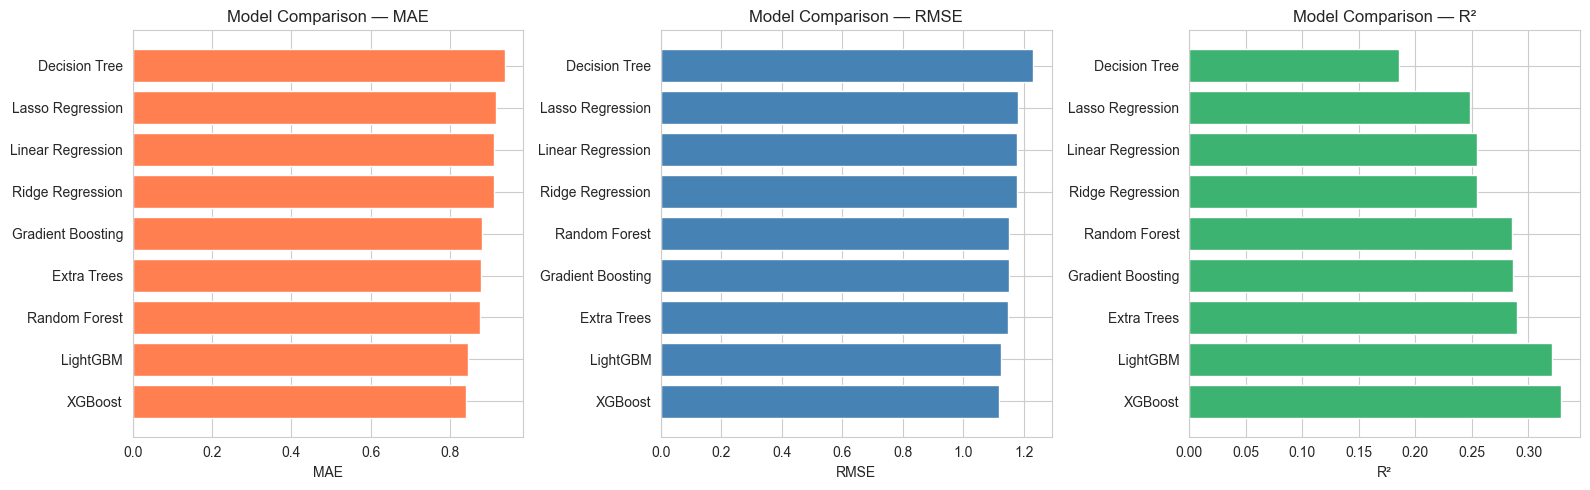

In [50]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R²']
colors  = ['coral', 'steelblue', 'mediumseagreen']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
    ax.barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()

## 8. Best Model — Deep Dive

In [51]:
# Use the best model (Random Forest or Gradient Boosting usually wins)
best_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda = 1.0,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test.values)

print(f'Best Model — Random Forest')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'  R²   : {r2_score(y_test, y_pred_best):.4f}')

Best Model — Random Forest
  MAE  : 0.8436
  RMSE : 1.1168
  R²   : 0.3291


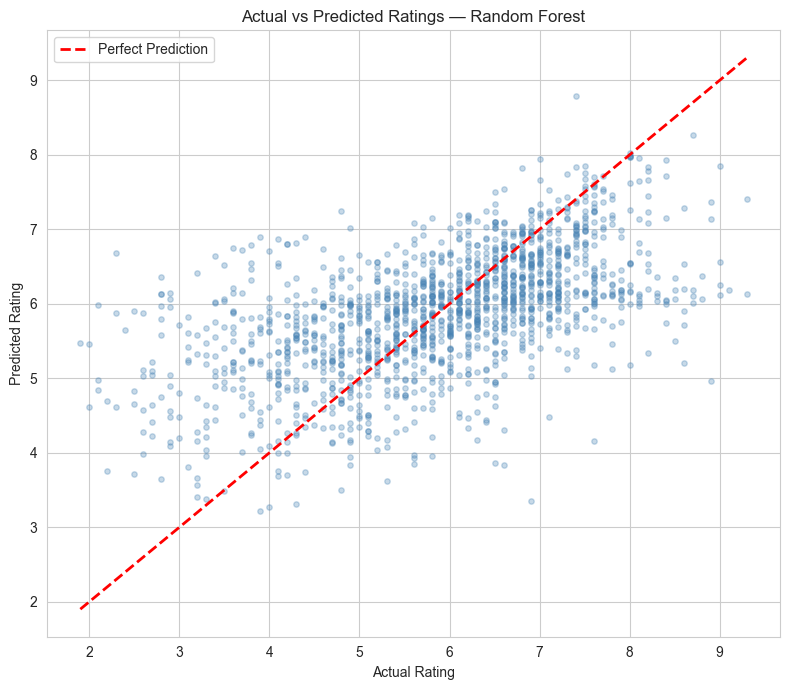

In [52]:
# Actual vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

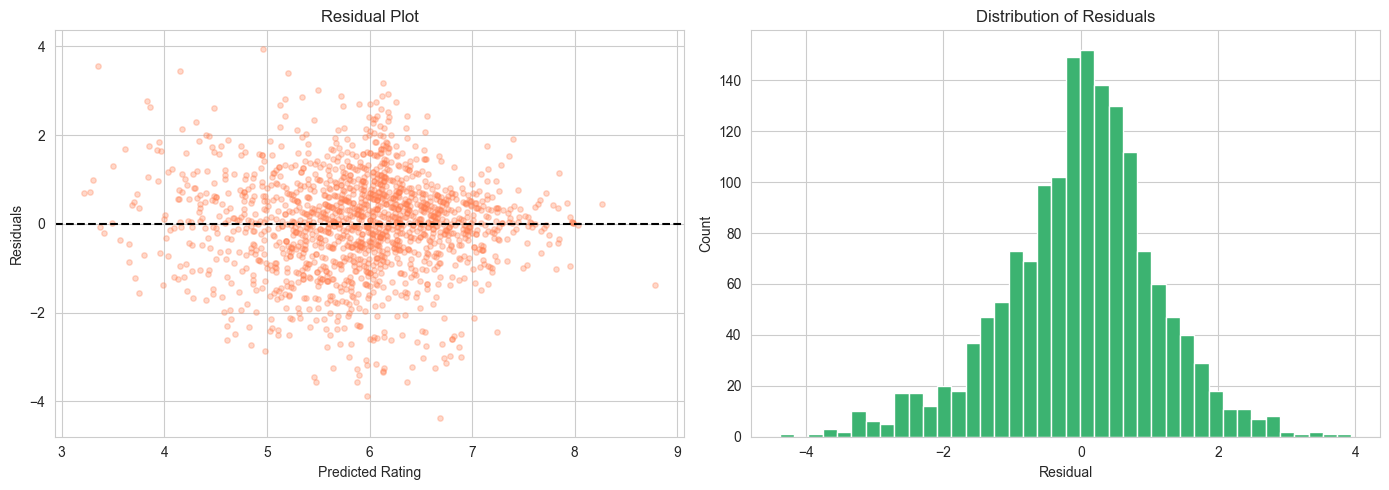

In [53]:
# Residual plot
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='coral', s=15)
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Rating')  
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

## 9. Feature Importance

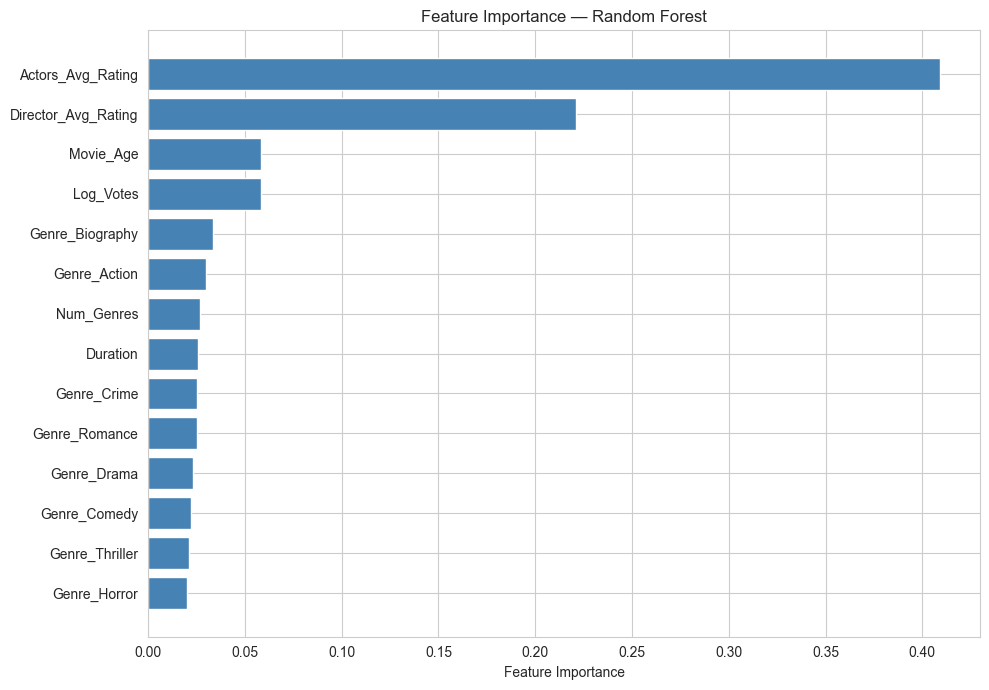

Top 5 most important features:
Actors_Avg_Rating      0.409356
Director_Avg_Rating    0.221010
Movie_Age              0.058406
Log_Votes              0.058185
Genre_Biography        0.033785
dtype: float32


In [54]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_imp.index, feat_imp.values, color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.sort_values(ascending=False).head())

## 11. Predict Rating for a New Movie

In [55]:
CURRENT_YEAR = df['Year'].max()
def predict_movie_rating(name, year, duration, genre, votes,
                         director, actor1=None, actor2=None, actor3=None,
                         model=best_model, imputer=imputer):

    votes = 0 if pd.isna(votes) else votes
    log_votes = np.log1p(votes)

    movie_age = CURRENT_YEAR - year
    genre_list = [g.strip().title() for g in genre.split(',') if g.strip()]
    num_genres = len(genre_list)

    dir_rating = director_smooth.get(director, global_mean)

    actor_vals = []

    if actor1 and actor1.strip():
        actor_vals.append(actor1_smooth.get(actor1, global_mean))
    if actor2 and actor2.strip():
        actor_vals.append(actor2_smooth.get(actor2, global_mean))
    if actor3 and actor3.strip():
        actor_vals.append(actor3_smooth.get(actor3, global_mean))

    actors_avg = np.mean(actor_vals) if actor_vals else global_mean

    genre_flags = [int(g in genre_list) for g in top_genres]

    row = [duration, log_votes, movie_age, num_genres,
           dir_rating, actors_avg] + genre_flags

    row_df = pd.DataFrame([row], columns=feature_cols)
    row_imputed = imputer.transform(row_df)

    predicted = model.predict(row_imputed)[0]
    predicted = np.clip(predicted, 1, 10)

    return predicted


# Example prediction
predict_movie_rating(
    name='My Sample Film',
    year=2019,
    duration=130,
    genre='Drama, Romance',
    votes=5000,
    director='Shoojit Sircar',
    actor1='Jimmy Sheirgill'
)

np.float32(5.299966)

In [56]:
import pickle

# Save the Random Forest model
with open('models/rf_movie_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the imputer
with open('models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Save the feature columns (needed for prediction)
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# Save smoothed averages and top genres
with open('models/global_mean.pkl', 'wb') as f:
    pickle.dump(global_mean, f)

with open('models/director_avg.pkl', 'wb') as f:
    pickle.dump(director_smooth.to_dict(), f)

with open('models/actor1_avg.pkl', 'wb') as f:
    pickle.dump(actor1_smooth.to_dict(), f)

with open('models/actor2_avg.pkl', 'wb') as f:
    pickle.dump(actor2_smooth.to_dict(), f)

with open('models/actor3_avg.pkl', 'wb') as f:
    pickle.dump(actor3_smooth.to_dict(), f)

with open('models/top_genres.pkl', 'wb') as f:
    pickle.dump(top_genres, f)

with open('models/current_year.pkl', 'wb') as f:
    pickle.dump(CURRENT_YEAR, f)